In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
# --- Parameters ---
T = 300.0                       # Temperature in Kelvin
kb = 0.008314462618             # Boltzmann constant in kJ/(mol K)
kT = kb * T                     # Thermal energy
bins = 100                      # Number of bins for your FES histogram

In [8]:
print("Loading weights_master.dat...")
# Load the 3 columns: [0] CV, [1] rbias, [2] walker_weight
data = np.loadtxt('weights_master.dat')

Loading weights_master.dat...


In [9]:
cv = data[:, 0]
rbias = data[:, 1]
we_weight = data[:, 2]

np.size(cv)

8556101

In [5]:
# --- 1. Calculate Combined Weights ---
print("Calculating combined thermodynamic weights...")
metad_weight = np.exp(rbias / kT)
total_weight = we_weight * metad_weight

Calculating combined thermodynamic weights...


In [6]:
# --- 2. Build the Histogram ---
print("Constructing the Free Energy Surface...")
# Create a 1D histogram of the CV weighted by the combined total weights
hist, bin_edges = np.histogram(cv, bins=bins, weights=total_weight)

# Calculate the center of each bin for plotting
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

Constructing the Free Energy Surface...


In [7]:
# --- 3. Convert Probability to Free Energy ---
# Add a tiny epsilon (1e-12) to prevent log(0) errors in empty bins
fes = -kT * np.log(hist + 1e-12)
# fes_act=fes
# Normalize the FES so the global minimum is exactly 0 kJ/mol
fes = fes - np.min(fes)

In [8]:
# --- 4. Save the Final Output ---
output_data = np.column_stack((bin_centers, fes))
np.savetxt('final_1D_FES.dat', output_data, header="RMSD(nm) Free_Energy(kJ/mol)", fmt='%.6f')

print("Success! Final FES saved to final_1D_FES.dat")

Success! Final FES saved to final_1D_FES.dat


<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\sonti\AppData\Local\Temp\ipykernel_8764\2737565087.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('RMSD ($\AA$)')
C:\Users\sonti\AppData\Local\Temp\ipykernel_8764\2737565087.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.title('ParMetaD (1.72 $\mu$s)')


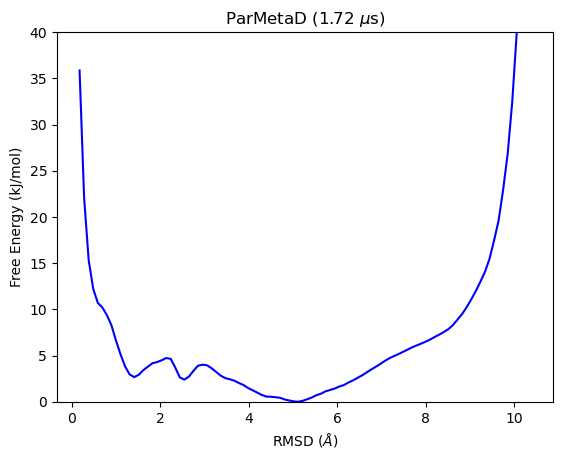

In [9]:
plt.plot(bin_centers*10,fes,'b')
plt.xlabel('RMSD ($\AA$)')
plt.ylabel('Free Energy (kJ/mol)')
plt.ylim(0,40)
plt.title('ParMetaD (1.72 $\mu$s)')
plt.savefig('Chignolin_FES.png',dpi=300,bbox_inches='tight')

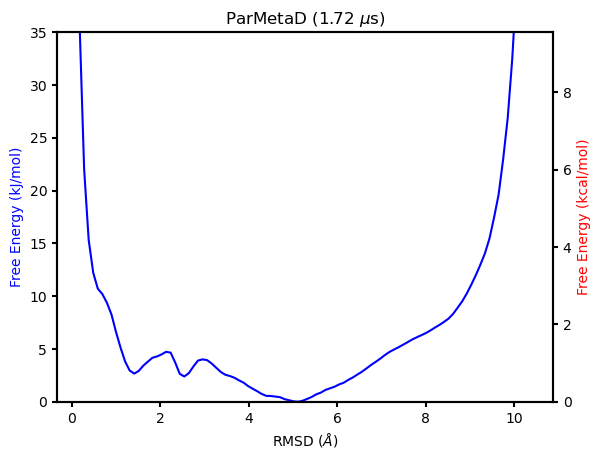

In [25]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Original plot (kJ/mol)
ax1.plot(bin_centers*10, fes, 'b')
ax1.set_xlabel('RMSD ($\\AA$)')
ax1.set_ylabel('Free Energy (kJ/mol)', color='b')
ax1.set_ylim(0, 35)

# Secondary axis (kcal/mol)
ax2 = ax1.twinx()

kJ_to_kcal = 0.239005736
ax2.set_ylim(0 * kJ_to_kcal, 40 * kJ_to_kcal)
ax2.set_ylabel('Free Energy (kcal/mol)', color='r')

# Title + save
plt.title('ParMetaD (1.72 $\\mu$s)')
plt.savefig('Chignolin_FES_both.png', dpi=300, bbox_inches='tight')
plt.show()

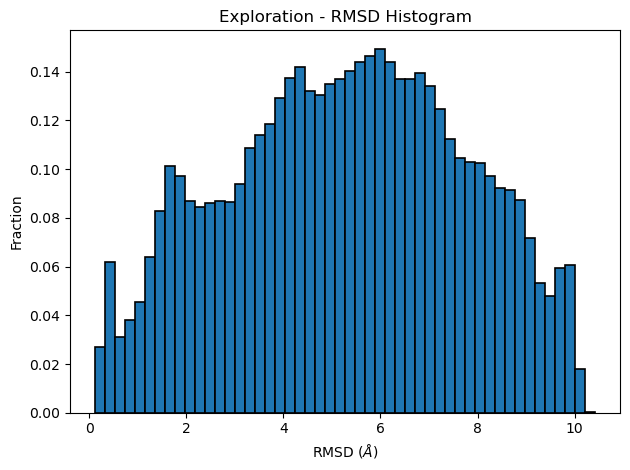

In [11]:
weights = np.ones_like(cv) / len(cv)
plt.hist(
    cv*10,
    bins=50,
    edgecolor='black',   # border color
    linewidth=1.2,
    density=True,# border thickness
    weights=weights
)

plt.xlabel("RMSD ($\\AA$)")
plt.ylabel("Fraction")
plt.title("Exploration - RMSD Histogram")

plt.tight_layout()
plt.savefig("cv_histogram.png", dpi=300)
plt.show()

In [3]:
print("Loading weights_master.dat...")
# Load the 3 columns: [0] CV, [1] rbias, [2] walker_weight
data_2 = np.loadtxt('weights_master_BPTI.dat')


Loading weights_master.dat...


In [4]:
cv_2 = data_2[:, 0]
rg_2 = data_2[:,1]
rbias_2 = data_2[:, 2]
we_weight_2 = data_2[:, 3]

print(cv_2[0],rg_2[0],rbias_2[0],we_weight_2[0])
print(np.size(cv_2))


-2.961807 -1.287611 0.0 0.2
35414000


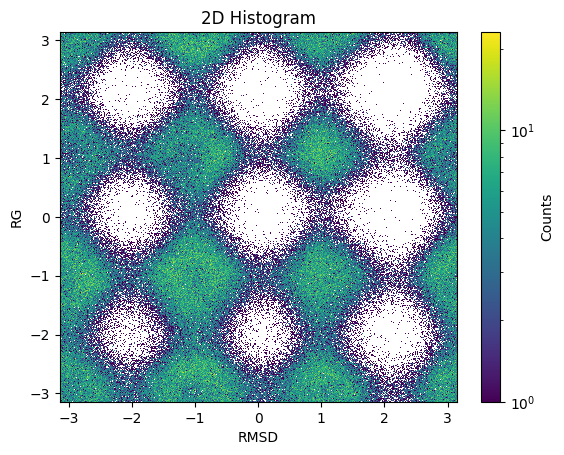

In [5]:
from matplotlib.colors import LogNorm

plt.hist2d(cv_2[0:2500000], rg_2[0:2500000], bins=1000,norm=LogNorm(vmin=1))   # adjust bins as needed
plt.colorbar(label='Counts')
plt.xlabel('RMSD')
plt.ylabel('RG')
plt.title('2D Histogram')
plt.show()


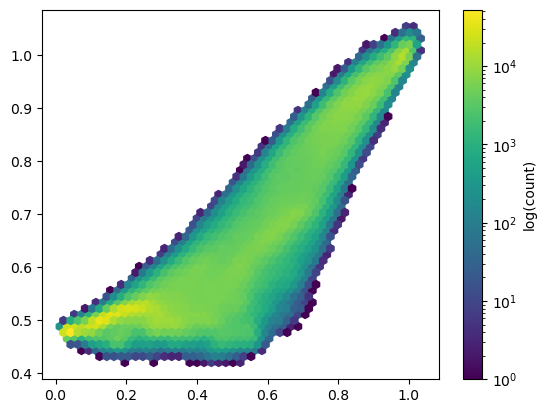

In [30]:
import seaborn as sns

plt.hexbin(cv_2, rg_2, gridsize=50, bins='log')
plt.colorbar(label='log(count)')

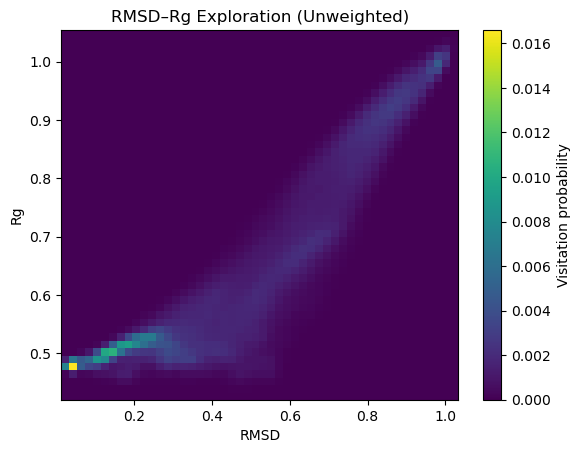

In [29]:
H, xedges, yedges = np.histogram2d(cv_2, rg_2, bins=50)
P = H / H.sum()

plt.imshow(
    P.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto'
)

plt.colorbar(label='Visitation probability')
plt.xlabel('RMSD')
plt.ylabel('Rg')
plt.title('RMSD–Rg Exploration (Unweighted)')
plt.show()

In [6]:
# --- 1. Calculate Combined Weights ---
print("Calculating combined thermodynamic weights...")
metad_weight_2 = np.exp(rbias_2 / kT)
total_weight_2 = we_weight_2 * metad_weight_2

Calculating combined thermodynamic weights...


In [7]:
# --- 2. Build the Histogram ---
print("Constructing the Free Energy Surface...")
# Create a 1D histogram of the CV weighted by the combined total weights
hist_2, bin_edges_2 = np.histogram(cv_2[0:2500000], bins=bins, weights=total_weight_2[0:2500000])

# Calculate the center of each bin for plotting
bin_centers_2 = (bin_edges_2[:-1] + bin_edges_2[1:]) / 2

Constructing the Free Energy Surface...


In [8]:
# --- 3. Convert Probability to Free Energy ---
# Add a tiny epsilon (1e-12) to prevent log(0) errors in empty bins
fes_2 = -kT * np.log(hist_2 + 1e-12)
# fes_act=fes
# Normalize the FES so the global minimum is exactly 0 kJ/mol
fes_2 = fes_2 - np.min(fes_2)
print(np.max(fes_2))

59.77288201133268


Text(0.5, 1.0, 'ParMetaD - RG-WESTPA (492 ns)')

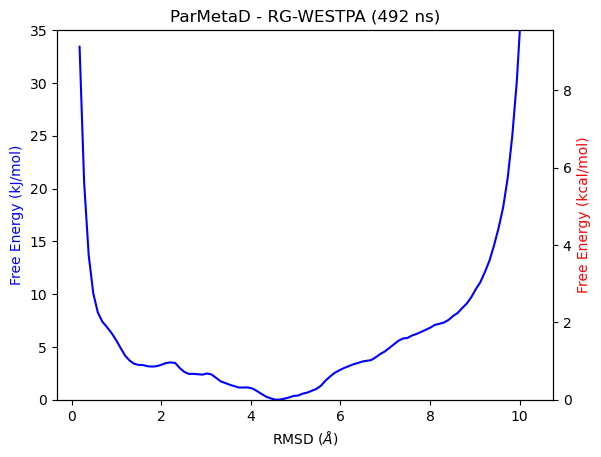

In [9]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Original plot (kJ/mol)
ax1.plot(bin_centers_2*10, fes_2, 'b')
ax1.set_xlabel('RMSD ($\\AA$)')
ax1.set_ylabel('Free Energy (kJ/mol)', color='b')
ax1.set_ylim(0, 35)

# Secondary axis (kcal/mol)
ax2 = ax1.twinx()

kJ_to_kcal = 0.239005736
ax2.set_ylim(0 * kJ_to_kcal, 40 * kJ_to_kcal)
ax2.set_ylabel('Free Energy (kcal/mol)', color='r')

# Title + save
plt.title('ParMetaD - RG-WESTPA (492 ns)')
# plt.savefig('ParMetaD_runRG.png', dpi=300, bbox_inches='tight')
# plt.show()

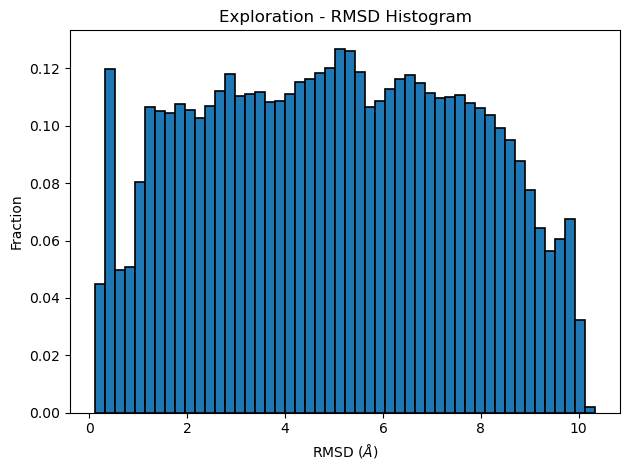

In [10]:
weights_2 = np.ones_like(cv_2) / len(cv_2)
plt.hist(
    cv_2*10,
    bins=50,
    edgecolor='black',   # border color
    linewidth=1.2,
    density=True,# border thickness
    weights=weights_2
)

plt.xlabel("RMSD ($\\AA$)")
plt.ylabel("Fraction")
plt.title("Exploration - RMSD Histogram")
# plt.savefig('ParMetaD_runRG_hist.png', dpi=300, bbox_inches='tight')
# plt.show()
plt.tight_layout()

In [12]:
# --- 1. Generate the 2D Histogram ---
# 'bins=100' is usually a good balance for 8.5M frames. 
# 'density=False' because we are providing weights manually.
hist, xedges, yedges = np.histogram2d(
    cv_2, 
    rg_2, 
    bins=100, 
    weights=total_weight, 
    range=[[0, 1.0], [0.4, 1.0]] # Adjust these ranges to fit your CV space
)

# --- 2. Convert to Free Energy ---
# FES = -kT * ln(P). Adding a tiny epsilon to avoid log(0)
epsilon = 1e-12 
fes = -kT * np.log(hist + epsilon)

# --- 3. Normalize ---
# We set the global minimum to 0 so the "deepest" basin is the reference point.
fes -= np.min(fes)

# --- 4. Plotting the Surface ---
plt.figure(figsize=(10, 8))

# Transpose 'fes' because np.histogram2d puts x on axis 0, but imshow wants it on axis 1
# 'extent' maps the plot coordinates to your actual RMSD and Rg values
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.imshow(
    fes.T, 
    cmap='viridis_r',  # _r reverses it so basins are dark/purple and peaks are yellow
    extent=extent, 
    aspect='auto', 
    origin='lower', 
    interpolation='gaussian'
)

# --- 5. Aesthetics ---
cbar = plt.colorbar()
cbar.set_label('Free Energy (kJ/mol)', fontsize=12)

plt.xlabel('RMSD (nm)', fontsize=14)
plt.ylabel('Radius of Gyration (nm)', fontsize=14)
plt.title('2D Free Energy Surface: Chignolin Folding', fontsize=16)

# plt.savefig("chignolin_2d_fes.png", dpi=300)
# plt.show()

NameError: name 'total_weight' is not defined

[Text(1, 0.0, '0.0'),
 Text(1, 0.8888888888888888, '0.9'),
 Text(1, 1.7777777777777777, '1.8'),
 Text(1, 2.6666666666666665, '2.7'),
 Text(1, 3.5555555555555554, '3.6'),
 Text(1, 4.444444444444445, '4.4'),
 Text(1, 5.333333333333333, '5.3'),
 Text(1, 6.222222222222221, '6.2'),
 Text(1, 7.111111111111111, '7.1'),
 Text(1, 8.0, '8.0')]

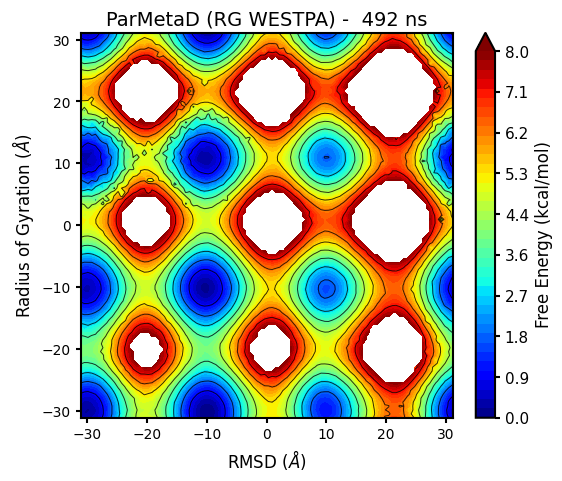

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup Constants & Convert Units ---
temp = 300
kb_kcal = 0.0019872  
kT = kb_kcal * temp
max_energy = 8.0  

# Convert CVs to Angstroms
cv_angstrom = cv_2 * 10.0
rg_angstrom = rg_2 * 10.0
rbias_kcal = rbias_2 / 4.184

# --- 2. Calculate Combined Weights ---
metad_weight_kcal = np.exp(rbias_kcal / kT)
total_weight_kcal = we_weight_2 * metad_weight_kcal

# --- 3. Generate the 2D Histogram ---
bins = 100
hist, xedges, yedges = np.histogram2d(
    cv_angstrom, 
    rg_angstrom, 
    bins=bins, 
    weights=total_weight_kcal
)

# Transpose for plotting orientation (X = cv, Y = rg)
hist = hist.T 

# --- 4. Convert to Free Energy (kcal/mol) ---
# Mask zero bins to avoid log(0) and np.nan issues in contours
masked_hist = np.ma.masked_where(hist == 0, hist)
fes_2d = -kT * np.log(masked_hist)

# Normalize so the global minimum is 0 kcal/mol
fes_2d -= np.min(fes_2d)

# Cap energy at 8.0 kcal/mol 
fes_2d[fes_2d > max_energy] = np.nan

# Calculate bin centers for contour plotting
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)

# --- 5. Global Matplotlib Styles (Matching Notebook) ---
plt.rcParams['axes.linewidth'] = 1.5      # Thicker axis border
plt.rcParams['xtick.major.width'] = 1.5   # Thicker tick marks
plt.rcParams['ytick.major.width'] = 1.5

# --- 6. Plotting ---
fig, ax = plt.subplots(figsize=(6, 5))

# Define contour levels (10 levels up to max_energy, exactly like your colorbar)
levels = np.linspace(0, max_energy, 40)  # 40 levels for smooth color gradients
tick_levels = np.linspace(0, max_energy, 10) # 10 levels for ticks/lines

# Plot the filled color surface
cf = ax.contourf(
    X, Y, fes_2d,
    levels=levels,
    cmap='jet',
    extend='max' # Arrows at the top of the colorbar
)

# Overlay the solid black contour lines
contours = ax.contour(
    X, Y, fes_2d,
    levels=tick_levels,
    colors='black',
    linewidths=0.7,
    alpha=0.8
)

# --- 7. Aesthetics and Labels ---
# Define axis limits specifically based on the reference image
# ax.set_xlim(0, 10)
# ax.set_ylim(3, 11)

ax.set_xlabel(r'RMSD ($\AA$)', fontsize=12)
ax.set_ylabel(r'Radius of Gyration ($\AA$)', fontsize=12)
ax.set_title(r'ParMetaD (RG WESTPA) -  492 ns', fontsize=14)

# Colorbar configuration matching the exact 10 ticks (0.0 to 8.0)
cbar = plt.colorbar(cf, ax=ax, ticks=tick_levels)
cbar.set_label('Free Energy (kcal/mol)', fontsize=12)
cbar.ax.tick_params(labelsize=11)
cbar.ax.set_yticklabels([f"{val:.1f}" for val in tick_levels]) # Force 1 decimal place

# plt.savefig("ParMetaD_FES_RG_2D.png", dpi=300, bbox_inches='tight')
# plt.show()

